# Расчетно Графическая Работа №1
## Вариант №1

> Численые методы анализа

> Выполнили: Егор Андреасян и Егор Захаров

> Группа: J3119



# Цель работы

Предложить среднеквадратическую аппроксимацию табличной функции многих переменных, проанализировать чувствительность точного решения к ошибкам округления, проверить сходимость расчетных и исходных данных

In [1]:
import random
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

SEED = 41
TEST_SIZE = 0.3

random.seed(SEED)
np.random.seed(SEED)

In [2]:
def plot_smart_boxplots(df: pd.DataFrame) -> list:
    sns.set_theme(style="whitegrid", palette="pastel")
    num_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [col for col in num_cols_raw if df[col].nunique() > 10]
    n_features = len(num_cols)
    if n_features == 0:
        return []
    if n_features <= 3:
        cols_in_row = n_features
    elif n_features == 4:
        cols_in_row = 2
    else:
        cols_in_row = 3 if n_features < 10 else 4
    rows = math.ceil(n_features / cols_in_row)
    fig, axes = plt.subplots(rows, cols_in_row,
                             figsize=(cols_in_row * 5, rows * 5),
                             squeeze=False)
    axes = axes.flatten()
    colors = sns.color_palette("pastel", n_colors=n_features)
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.boxplot(
            y=df[col], 
            ax=ax, 
            color=colors[i],
            width=0.4,
            fliersize=3,
            linewidth=1.5
        )
        ax.set_title(f"{col}", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('')
    for j in range(n_features, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
    return num_cols

# Смотрим данные

In [3]:
data = pd.read_csv('data/housing.csv', delimiter=';')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [4]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

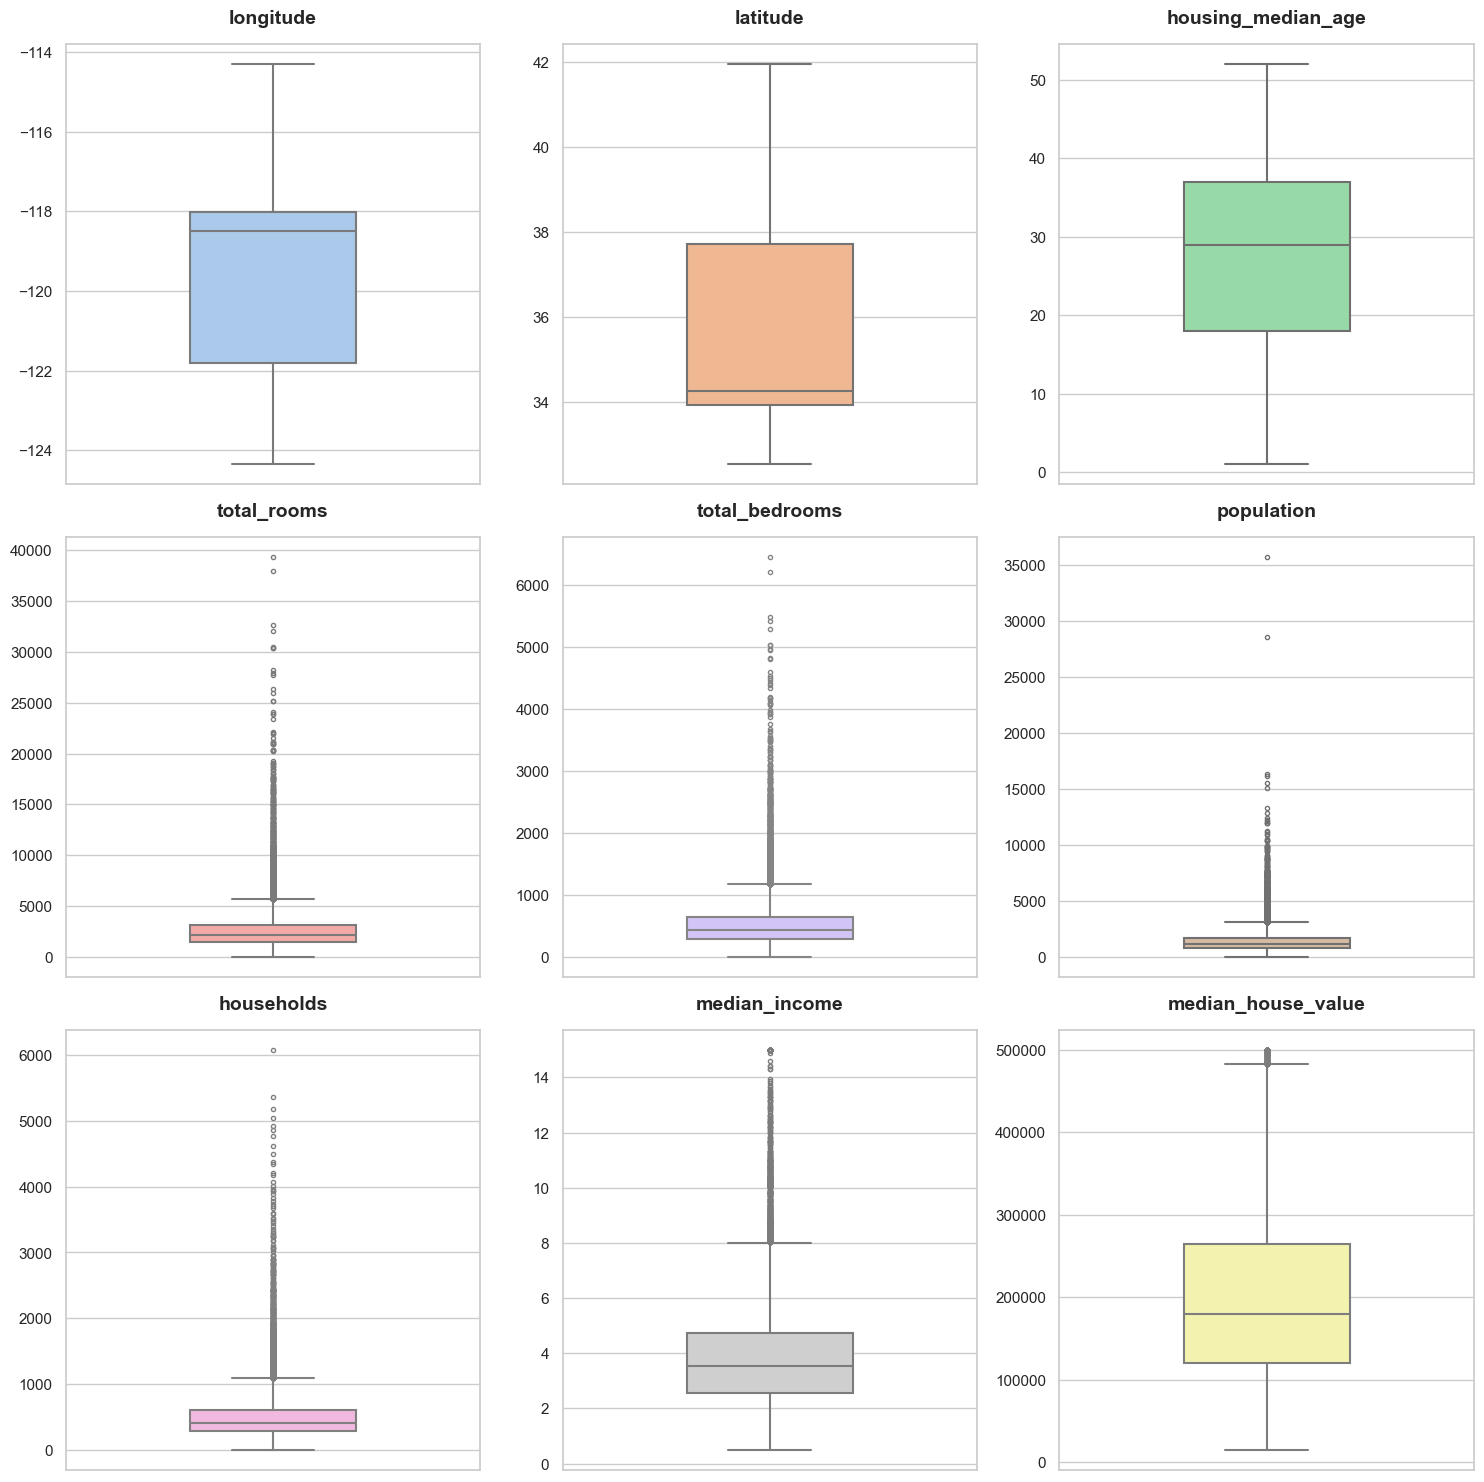

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [5]:
plot_smart_boxplots(data)

<Axes: >

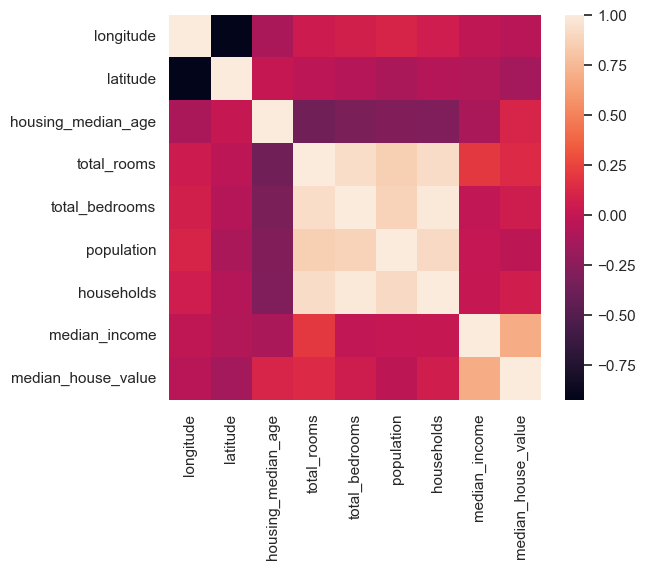

In [6]:
sns.set(rc={'figure.figsize': (6, 5)})
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix)

In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
data.fillna(data.median().astype(int), inplace=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


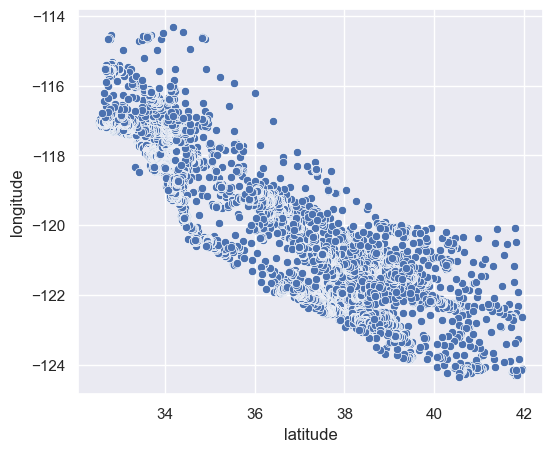

In [9]:
sns.scatterplot(data=data, x="latitude", y="longitude");

In [10]:
fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",
                        mapbox_style="open-street-map", zoom=4)
fig.show()

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/895364316.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",


Данные с штата Калифорния в дальнейшем можно прикольные данные из этого взять

In [11]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


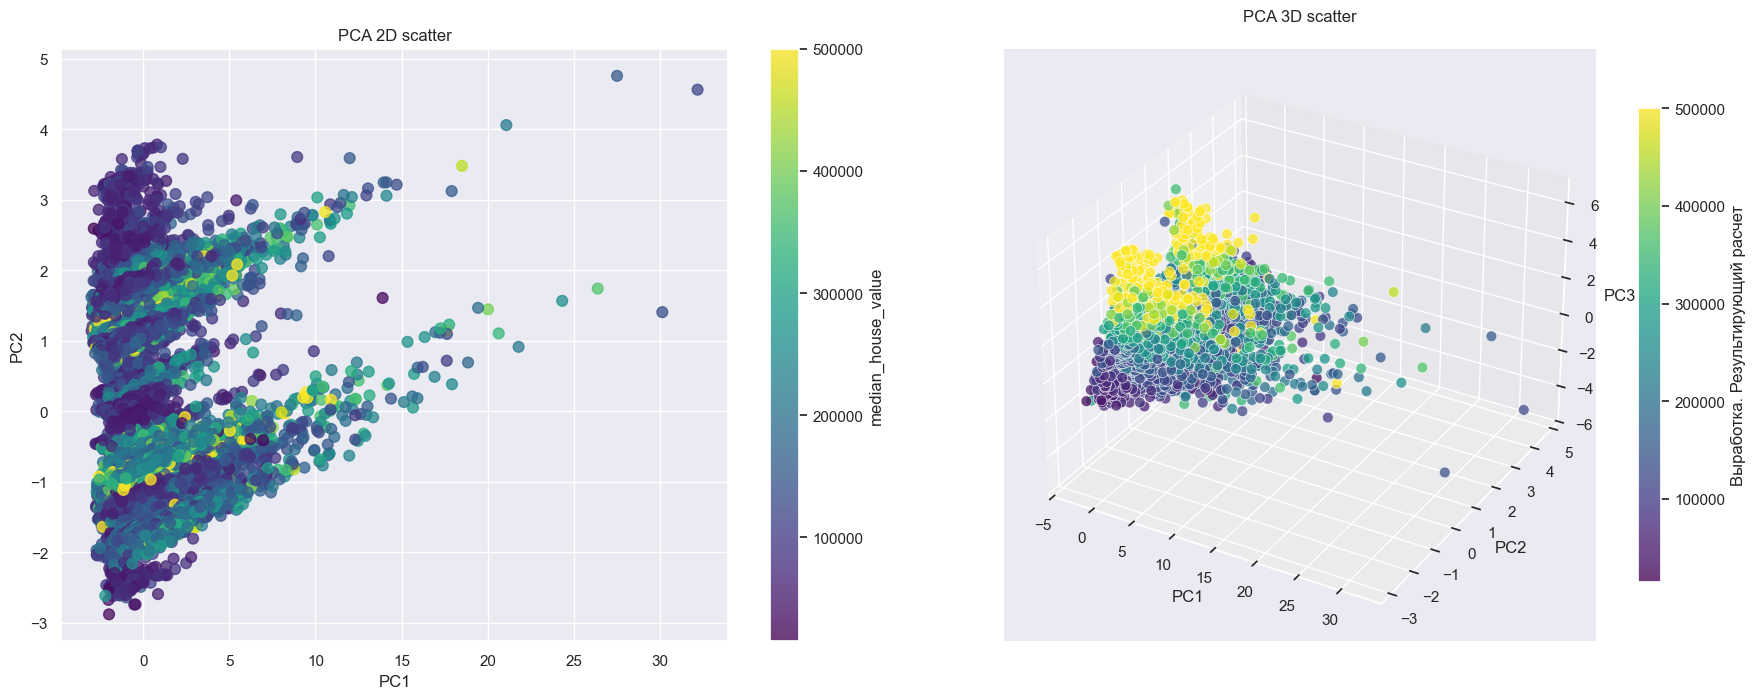

In [ ]:
X_scaled = StandardScaler().fit_transform(
    data.drop(columns=['median_house_value'])
)
target = data.dropna()['median_house_value'].values
pca_2d = PCA(n_components=2, random_state=SEED)
pcs_2d = pca_2d.fit_transform(X_scaled)
pca_3d = PCA(n_components=3, random_state=SEED)
pcs_3d = pca_3d.fit_transform(X_scaled)
fig = plt.figure(figsize=(18, 7))
ax1 = fig.add_subplot(1, 2, 1)
sc1 = ax1.scatter(
    pcs_2d[:, 0], pcs_2d[:, 1],
    c=target,
    cmap='viridis',
    alpha=0.75,
    s=60
)
ax1.set_title('PCA 2D scatter')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('median_house_value')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(
    pcs_3d[:, 0], pcs_3d[:, 1], pcs_3d[:, 2],
    c=target,
    cmap='viridis',
    alpha=0.75,
    s=60,
    edgecolors='white',
    linewidth=0.5
)
ax2.set_title('PCA 3D scatter', pad=20)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
cbar2 = plt.colorbar(sc2, ax=ax2, shrink=0.8, label='Выработка. Результирующий расчет')
plt.tight_layout()
plt.show()

# Класс линейной регрессии и метрики

В ообще самая простая реалиация и вид линейной регрессии такой

$$
f(x) = Xw
$$

$$
X \text{ - матрица, наши данные где колонки - это признаки, а строки - просто следующие данные которые надо рассчитать}
$$

$$
w \text{ - наши веса}
$$

В теории лабы написано что есть еще случайная ошиба, но в большинстве источников все ее сокращают и убирают из формулы [один из источникв](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/lecture-notes/lecture02-linregr.pdf)

Теперь связь со СЛАУ и МНК и тд, в чем вообще прикол, если пришлядеться то можно увидеть вообще такую картину

$$
Xw=y
$$

По факту наше СЛАУ ищим вектор весов $w$ чтобы получить наши таргеты $y$

Теперь причем тут МНК, если мы просто вычислим $w$ то какое-то отличие всеравно будет, и поэтому можно применить МНК, вычисляя веса так чтобы ошибка была минимальной

Ошибка выглядит так

$$
error = ||Xw - y|| ^ 2
$$

распишем

$$
error = ||Xw - y|| ^ 2 = (Xw - y)^T(Xw - y)= (w^TX^T - y^T)(Xw - y) = w^TX^TXw − w^TX^Ty − y^TXw + y^Ty \\
$$

$$
w^TX^Ty = (w^TX^Ty)^T = y^TXw
$$

$$
error = w^TX^TXw − 2w^TX^Ty + y^Ty
$$

Теперь посчитаем градиент

$$
\nabla error_w = 2X^TXw - 2X^Ty + 0
$$

$$
\nabla error_w = 2X^TXw - 2X^Ty
$$

Теперь нам нужен минимум ошибки, что делаем? очев

$$
\nabla error_w = 0
$$

$$
2X^TXw - 2X^Ty = 0
$$

$$
2X^TXw = 2X^Ty
$$

и тут мы получили СЛАУ, ищим мы $w$

$$
w = (X^TX)^{-1}X^Ty
$$

и по факту все, это как один из способов, либо можно искать веса через градиентный спуск

МНК это вообще наш критерий что он говорит, минимизируем квадрат ошибки и все 

In [13]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [14]:
def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []
    for name, model in models.items():
        preds_train = model.predict(X_train)
        preds_test = model.predict(X_test)
        mae_train = mean_absolute_error(y_train, preds_train)
        mae_test = mean_absolute_error(y_test, preds_test)
        mse_train = mean_squared_error(y_train, preds_train)
        mse_test = mean_squared_error(y_test, preds_test)
        results.append({
            "Model": name,
            "MAE_train": f"{mae_train:.4f}",
            "MAE_test": f"{mae_test:.4f}",
            "MSE_train": f"{mse_train:.4f}",
            "MSE_test": f"{mse_test:.4f}",
        })
    df = pd.DataFrame(results).set_index("Model")
    return df

In [15]:
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y, fit_var: str='inv', iter: int=1024, learning_rate: float=0.01, eps: float= 1e-8, delta: float=1e-8):
        if fit_var == 'inv':
            self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        elif fit_var == 'solve':
            self.w = np.linalg.solve(X.T @ X, X.T @ y)
        elif fit_var == 'lstsq':
            self.w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        elif fit_var == 'grad':
            self._fit_gradient_lin_reg(X, y, iter, learning_rate, eps, delta)
        else:
            raise ValueError(f"Unknown fit_var: {fit_var}")
    
    def _fit_gradient_lin_reg(self, X, y, iter, learning_rate, eps, delta):
        n = X.shape[0]
        self.w = np.zeros(X.shape[1])
        best_w = self.w.copy()
        best_error = np.inf
        for i in range(iter):
            pred = X @ self.w
            error = np.mean(np.abs(pred - y) ** 2)
            # grad = 2 * X.T @ X @ self.w - 2 * X.T @ y # спрашивал у клода почему тут все так плохо и почему-то тут 
            # не стабильный подсчет идет и поэтому надо подругому
            grad = (2 / n) * X.T @ (pred - y)
            self.w -= learning_rate * grad
            if error < best_error:
                best_error = error
                best_w = self.w.copy()
            if error < eps or np.linalg.norm(grad) < delta:
                break
        self.w = best_w

    def predict(self, X):
        return X @ self.w

# train test split

## Делим

In [16]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [17]:
X = data.drop(columns=["median_house_value"]).values
Y = data["median_house_value"].values

In [ ]:
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=SEED
)

# Посмотр метрики без предобработок

In [19]:
lr_inv = LinearRegression()
lr_inv.fit(X_train, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [ ]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train, Y_train,
    X_valid, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),55442.7324,55160.7128,5625441737.0194,5607494278.1819
Linear Regression (Solve),55442.7324,55160.7128,5625441737.0194,5607494278.1819
Linear Regression (Lstsq),55442.7324,55160.7128,5625441737.0194,5607494278.1819
Linear Regression (Grad),4129412601.5468,4132070584.6593,27859668016988680192.0000,27864884821729521664.0000


In [21]:
XTX = X_train.T @ X_train

cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 8745659.784579469


# Эксперименты с предобработкой

Нужно перебрать такие форматы параметров

| № | StandardScaler |  | Poly | MAE |  | Число обуч. |
|---|-----------------|--|------|-----|--|--------------|
|   | mean | std | degree | train | test | |
| 1 | False | False | 1 | ... | ... | ... |
| 2 | True  | False | 1 | ... | ... | ... |
| 3 | False | True  | 1 | ... | ... | ... |
| 4 | True  | True  | 1 | ... | ... | ... |
| 5 | True  | True  | 2 | ... | ... | ... |
| 6 | True  | True  | 3 | ... | ... | ... |

StandardScaler - обычное масштабирование данных

PolynomialFeatures - это уже прикольная штука, полимиальные комбинации, т е мы берем все наши фичи и делаем разные взаимодействия над каждой фичей либо над фичами в паре и тд, возводим в квадрат или переменожает друг с другом и тд зависит от degree

## StandardScaler без параметров(просто посмотрим)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

<Axes: >

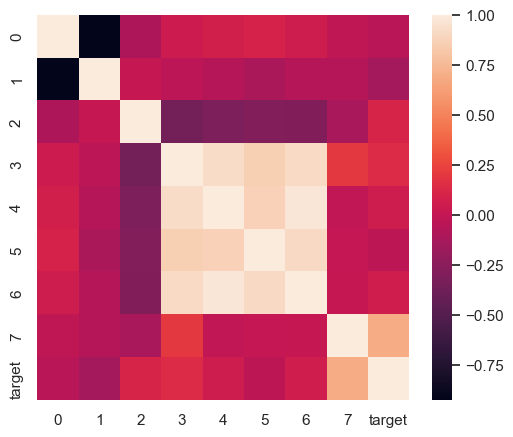

In [23]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [ ]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),207500.7322,206143.1498,47863131111.6764,47261273865.5328
Linear Regression (Solve),207500.7322,206143.1498,47863131111.6764,47261273865.5328
Linear Regression (Lstsq),207500.7322,206143.1498,47863131111.6764,47261273865.5328
Linear Regression (Grad),207462.7800,205845.9848,49046435974.9827,48406732587.9625


In [26]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 180.07109852333164


## PolynomialFeatures с базовыми настройками

In [27]:
polym_f = PolynomialFeatures(include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

<Axes: >

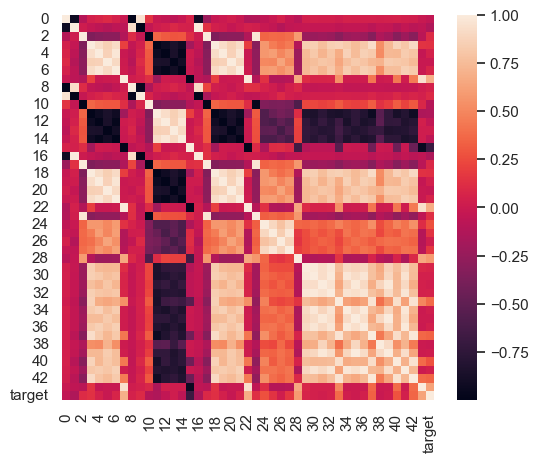

In [28]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_poly)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [29]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_poly, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_poly, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_poly, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_poly, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [30]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_poly, Y_train,
    X_valid_poly, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),45156.8323,45616.8892,4011875897.3471,4201540463.2978
Linear Regression (Solve),45156.8324,45616.8893,4011875897.3471,4201540463.3728
Linear Regression (Lstsq),45156.8329,45616.8900,4011875897.3471,4201540503.2510
Linear Regression (Grad),88604380264629760.0000,88604417006256368.0000,87166892400980254852942263641702400.0000,73125736860508466601892131622617088.0000


In [31]:
XTX = X_train_poly.T @ X_train_poly

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

Число обусловленности X^T X: 2.1344500551199236e+19


In [32]:
# Сохраняем результаты каждого эксперимента для графиков
all_results = []

# №1
| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 1 | False | False | 1 |

In [33]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=False, with_std=False)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

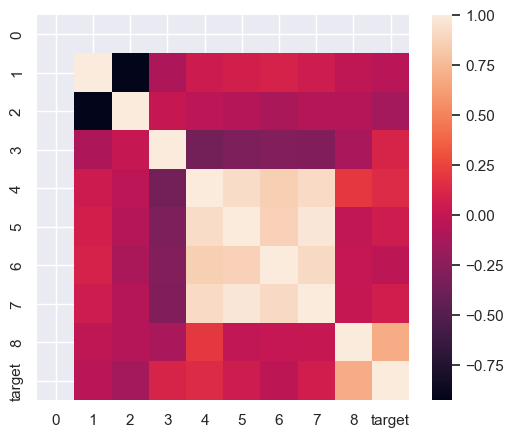

In [34]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [35]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [36]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),50980.2297,51213.5304,4841403607.8073,4887151428.9309
Linear Regression (Solve),50980.2297,51213.5304,4841403607.8073,4887151428.9318
Linear Regression (Lstsq),50980.2297,51213.5304,4841403607.8073,4887151428.9062
Linear Regression (Grad),4129413016.3804,4132070999.4929,27859671443026993152.0000,27864888249973067776.0000


In [37]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '1',
    'mean': False,
    'std': False,
    'degree': 1,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 259815917560.25336


# №2
| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 2 | True  | False | 1 |

In [38]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=False)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

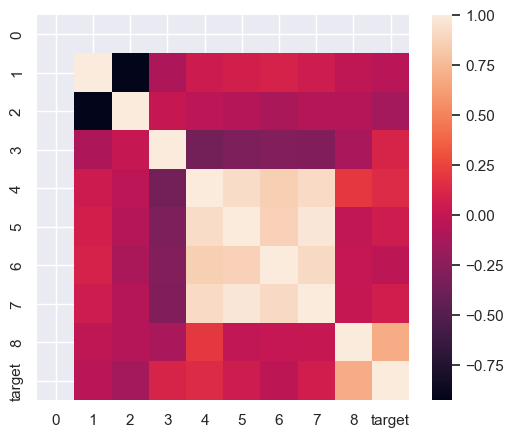

In [39]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [40]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [41]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Solve),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Lstsq),50980.2297,51213.5304,4841403607.8073,4887151428.9063
Linear Regression (Grad),90399476.7561,91267801.2465,21503786620749048.0000,21630062524640932.0000


In [42]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '2',
    'mean': True,
    'std': False,
    'degree': 1,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 24499721.005351298


# №3

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 3 | False | True  | 1 |

In [43]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=False, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

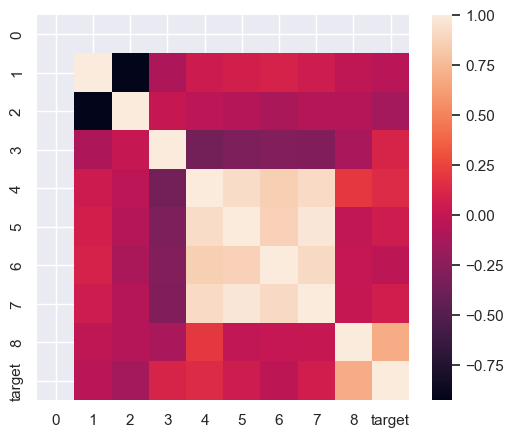

In [44]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [45]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

/opt/homebrew/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:24: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)
/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_38171/249360594.py:28: RuntimeWarning: invalid value encountered in subtract
  self.w -= learning_rate * grad


In [46]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),50980.2297,51213.5304,4841403607.8073,4887151428.8969
Linear Regression (Solve),50980.2297,51213.5304,4841403607.8073,4887151428.8963
Linear Regression (Lstsq),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Grad),1390778.1163,1392413.0017,1948265244186.6978,1952964895754.7173


In [47]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '3',
    'mean': False,
    'std': True,
    'degree': 1,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 64380096.27540791


# №4

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 4 | True | True  | 1 |

In [48]:
polym_f = PolynomialFeatures(degree=1, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

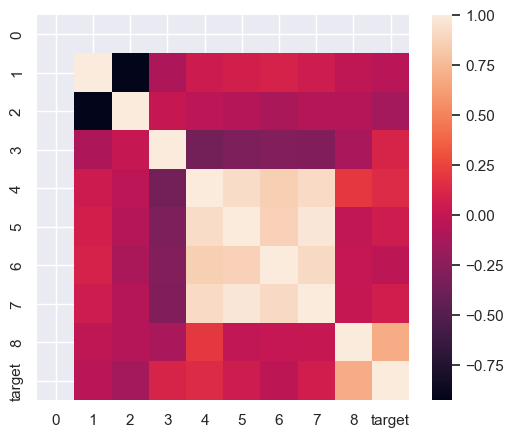

In [49]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [50]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [51]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Solve),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Lstsq),50980.2297,51213.5304,4841403607.8073,4887151428.9061
Linear Regression (Grad),57270.0634,57095.6741,6737621253.6652,6732184112.3552


In [52]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '4',
    'mean': True,
    'std': True,
    'degree': 1,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 180.07109852333102


# №5

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 5 | True | True  | 2 |

In [53]:
polym_f = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

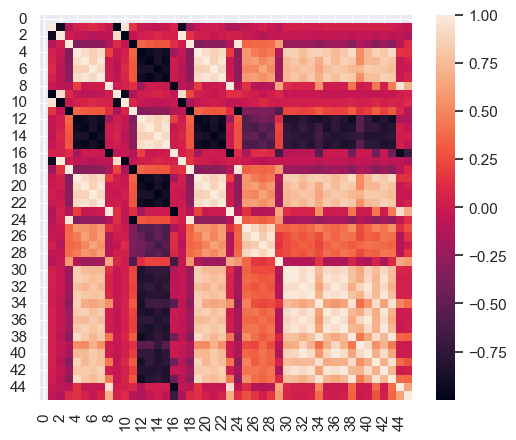

In [54]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [55]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [56]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),45061.8361,45512.3635,4006121376.9575,4199861940.3951
Linear Regression (Solve),45061.8361,45512.3635,4006121376.9575,4199861940.3889
Linear Regression (Lstsq),45061.8361,45512.3635,4006121376.9575,4199861940.3343
Linear Regression (Grad),53418.9642,53085.1762,6007752172.5374,5994726136.4124


In [57]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '5',
    'mean': True,
    'std': True,
    'degree': 2,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 52852716.51886541


# №6

| № | StandardScaler |  | Poly |
|---|-----------------|--|------|
|   | mean | std | degree |
| 6 | True | True  | 3 |

In [58]:
polym_f = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = polym_f.fit_transform(X_train)
X_valid_poly = polym_f.transform(X_valid)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_poly)
X_valid_scaled = scaler.transform(X_valid_poly)

X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_valid_scaled = np.hstack([np.ones((X_valid_scaled.shape[0], 1)), X_valid_scaled])

<Axes: >

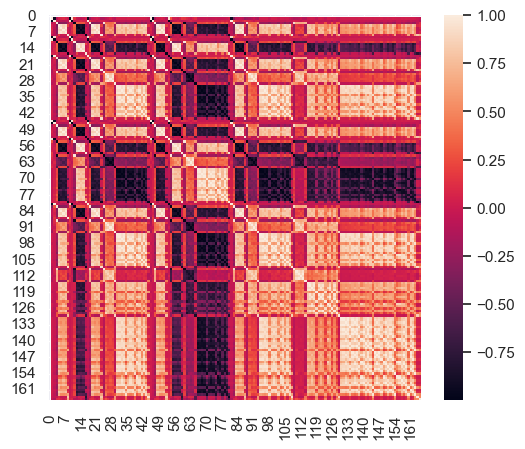

In [59]:
sns.set(rc={'figure.figsize': (6, 5)})
dt = pd.DataFrame(X_train_scaled)
dt['target'] = Y_train
correlation_matrix = dt.corr()
sns.heatmap(correlation_matrix)

In [60]:
lr_inv = LinearRegression()
lr_inv.fit(X_train_scaled, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train_scaled, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train_scaled, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train_scaled, Y_train, fit_var='grad', learning_rate=0.001)

In [61]:
evaluate_models(
    {
        'Linear Regression (Inv)': lr_inv,
        'Linear Regression (Solve)': lr_solve,
        'Linear Regression (Lstsq)': lr_lstsq,
        'Linear Regression (Grad)': lr_grad
    },
    X_train_scaled, Y_train,
    X_valid_scaled, Y_valid
)

,MAE_train,MAE_test,MSE_train,MSE_test
Model,,,,
Linear Regression (Inv),41621.8817,43085.5730,3442364984.6130,5187861893.9386
Linear Regression (Solve),41621.8692,43085.5645,3442364984.4204,5187865491.3687
Linear Regression (Lstsq),41621.8690,43085.5461,3442364983.8369,5187839284.8429
Linear Regression (Grad),51272.7377,50949.4013,5496094145.5729,5487364004.1921


In [62]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond}")

# Сохраняем результаты
mae_tr = mean_absolute_error(Y_train, lr_lstsq.predict(X_train_scaled))
mae_te = mean_absolute_error(Y_valid, lr_lstsq.predict(X_valid_scaled))
all_results.append({
    '№': '6',
    'mean': True,
    'std': True,
    'degree': 3,
    'MAE_train': round(mae_tr, 4),
    'MAE_test': round(mae_te, 4),
    'cond': cond,
})

Число обусловленности X^T X: 6323926982886.163


# Анализ результатов

| № | StandardScaler | | Poly | MAE | | Число обуч. |
|---|---|---|---|---|---|---|
| | mean | std | degree | train | test | |
| 1 | False | False | 1 | 50980.2297 | 51213.5304 | 259815917560.25 |
| 2 | True | False | 1 | 50980.2297 | 51213.5304 | 24499721.01 |
| 3 | False | True | 1 | 50980.2297 | 51213.5304 | 64380096.28 |
| 4 | True | True | 1 | 50980.2297 | 51213.5304 | 180.07 |
| 5 | True | True | 2 | 45061.8361 | 45512.3635 | 52852716.52 |
| 6 | True | True | 3 | 41621.8690 | 43085.5461 | 6323926982886.16 |

### Как масштабирование признаков влияет на качество модели?

MAE в экспериментах 1-4 одинаковый (train: 50980, test: 51213). Это объясняется тем, что аналитическое решение $w^* = (X^TX)^{-1}X^Ty$ находит одну и ту же модель — масштабирование меняет масштаб весов, но предсказания остаются теми же.

Однако масштабирование **критически влияет на число обусловленности**:

- Без стандартизации: $k \approx 2.6 \cdot 10^{11}$ — матрица почти вырождена

- Только центрирование (mean=True): $k \approx 2.4 \cdot 10^{7}$ — лучше, но всё ещё плохо

- Только нормировка (std=True): $k \approx 6.4 \cdot 10^{7}$ — аналогично

- Полная стандартизация (mean+std): $k \approx 180$ — отличная обусловленность


Причина: без стандартизации признаки имеют разные масштабы (например, `population` — тысячи, `latitude` — десятки). Матрица $X^TX$ получает сильно различающиеся собственные значения, что делает решение СЛАУ чувствительным к ошибкам округления. При полной стандартизации все признаки приводятся к одному масштабу, и матрица становится хорошо обусловленной.

### Как изменяется качество при увеличении степени полинома?

- degree=1: MAE_test = 51213
- degree=2: MAE_test = 45512
- degree=3: MAE_test = 43085

PolynomialFeatures добавляет нелинейные комбинации признаков ($x_i^2$, $x_i x_j$, $x_i^3$ и т.д.). Зависимость цены жилья от признаков нелинейная, поэтому квадратичные и кубические члены позволяют модели лучше аппроксимировать реальную зависимость.

### Есть ли признаки переобучения?

Да, переобучение начинает проявляться при увеличении degree:
- degree=1: разница MAE train/test = 233
- degree=2: разница MAE train/test = 451
- degree=3: разница MAE train/test = 1464

Разница между ошибкой на обучающей и тестовой выборках растёт — модель всё лучше запоминает обучающие данные, но хуже обобщает на новые. При дальнейшем увеличении degree модель может полностью развалиться.

### Как число обусловленности связано с качеством модели?

Число обусловленности при полной стандартизации (mean+std):
- degree=1: $k \approx 180$
- degree=2: $k \approx 5.3 \cdot 10^{7}$
- degree=3: $k \approx 6.3 \cdot 10^{12}$

С ростом degree число обусловленности растёт экспоненциально. Это происходит потому, что полиномиальные признаки высоких степеней сильно коррелированы между собой (например $x_i^2$ и $x_i^3$ почти линейно зависимы), что делает матрицу $X^TX$ почти вырожденной. При $k > 10^{12}$ решение СЛАУ становится численно ненадёжным — мелкие изменения в данных могут привести к сильным изменениям весов.

### Какая комбинация параметров даёт наилучший результат?

По MAE на тестовой выборке лучший результат — эксперимент №6 (mean=True, std=True, degree=3) с MAE_test = 43085. Однако число обусловленности при этом крайне велико ($k \approx 6.3 \cdot 10^{12}$), что говорит о численной нестабильности решения. Оптимальным компромиссом между качеством и устойчивостью является эксперимент №5 (mean=True, std=True, degree=2) с MAE_test = 45512 и $k \approx 5.3 \cdot 10^{7}$.

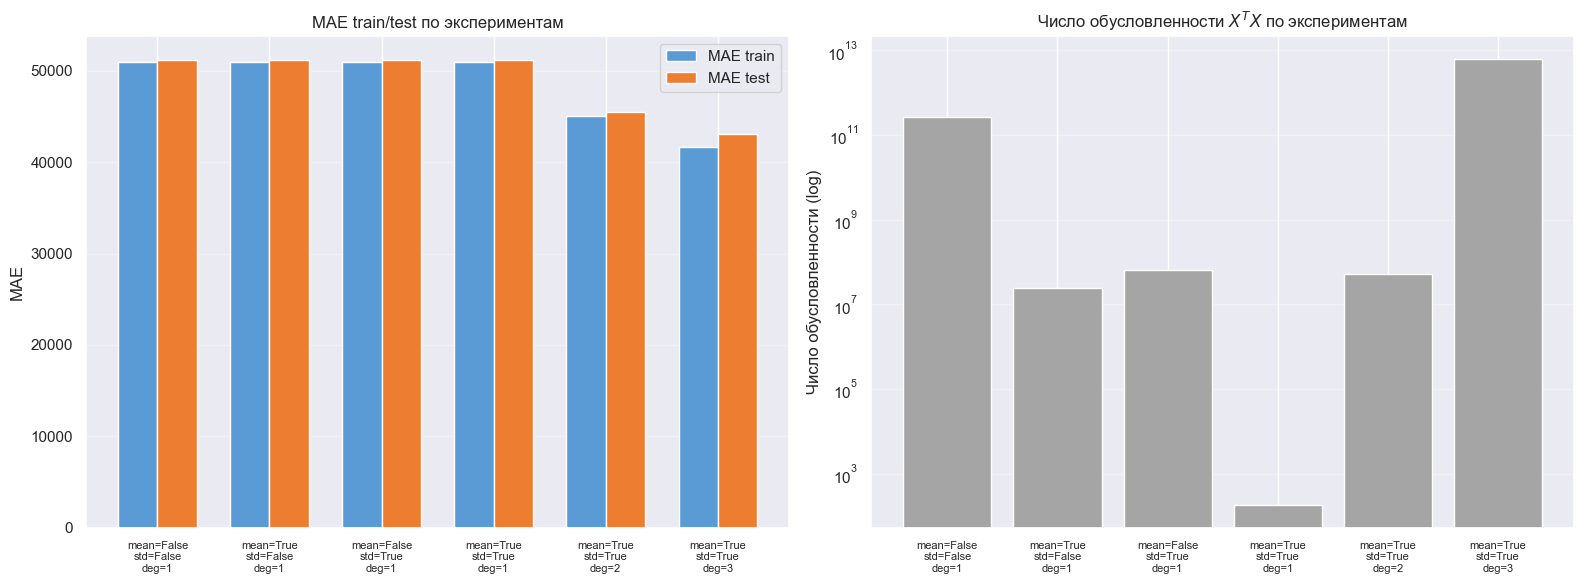

In [63]:
results_df = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = [f"mean={r['mean']}\nstd={r['std']}\ndeg={r['degree']}" for r in all_results]
x = np.arange(len(all_results))
width = 0.35

axes[0].bar(x - width/2, results_df['MAE_train'], width, label='MAE train', color='#5B9BD5')
axes[0].bar(x + width/2, results_df['MAE_test'], width, label='MAE test', color='#ED7D31')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE train/test по экспериментам')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, results_df['cond'], color='#A5A5A5')
axes[1].set_yscale('log')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Число обусловленности (log)')
axes[1].set_title('Число обусловленности $X^TX$ по экспериментам')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

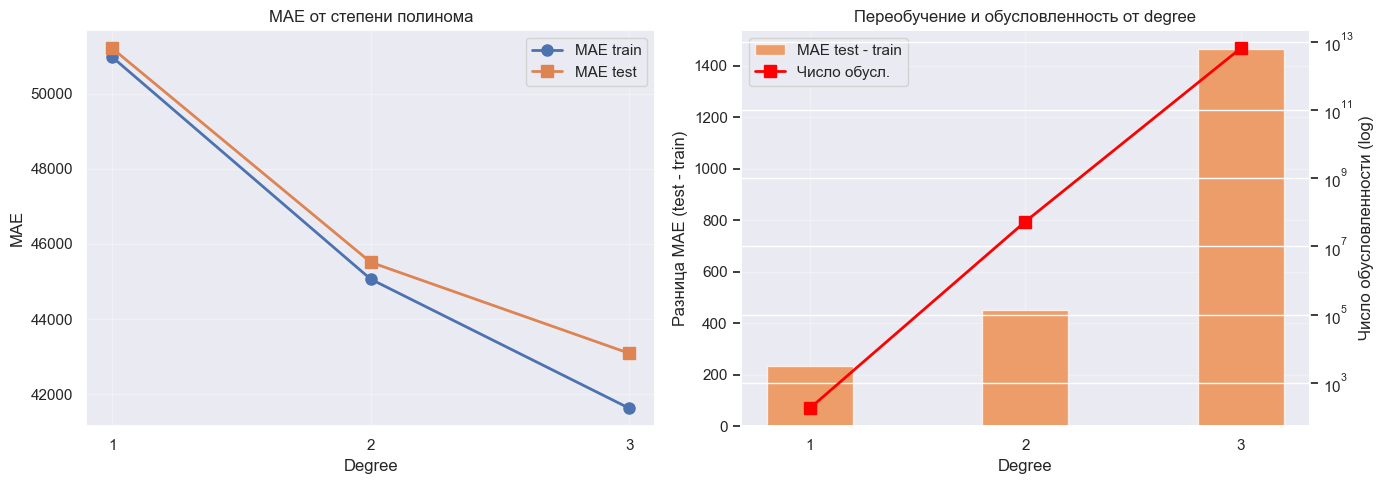

In [64]:
degree_df = results_df[results_df['mean'] & results_df['std']].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degree_df['degree'], degree_df['MAE_train'], 'o-', label='MAE train', markersize=8, linewidth=2)
axes[0].plot(degree_df['degree'], degree_df['MAE_test'], 's-', label='MAE test', markersize=8, linewidth=2)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE от степени полинома')
axes[0].set_xticks(degree_df['degree'].values)
axes[0].legend()
axes[0].grid(alpha=0.3)

ax_left = axes[1]
ax_right = ax_left.twinx()

diff = degree_df['MAE_test'].values - degree_df['MAE_train'].values
ax_left.bar(degree_df['degree'], diff, width=0.4, color='#ED7D31', alpha=0.7, label='MAE test - train')
ax_right.plot(degree_df['degree'], degree_df['cond'], 's-', color='red', markersize=8, linewidth=2, label='Число обусл.')
ax_right.set_yscale('log')

ax_left.set_xlabel('Degree')
ax_left.set_ylabel('Разница MAE (test - train)')
ax_right.set_ylabel('Число обусловленности (log)')
ax_left.set_title('Переобучение и обусловленность от degree')
ax_left.set_xticks(degree_df['degree'].values)

lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax_left.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы о влиянии предобработки на качество модели

### Масштабирование (StandardScaler)

Масштабирование не влияет на качество аналитического решения — MAE во всех экспериментах с degree=1 одинаковый. Это логично: формула $w^* = (X^TX)^{-1}X^Ty$ компенсирует разницу масштабов через веса. Однако масштабирование критически важно для **численной устойчивости** — число обусловленности падает с $2.6 \cdot 10^{11}$ до $180$ при включении обоих параметров (mean + std). На практике это означает, что без стандартизации решение СЛАУ чувствительно к ошибкам округления, а при использовании итеративных методов (градиентный спуск) модель без стандартизации вообще не сходится.

### Полиномиальные признаки (PolynomialFeatures)

Увеличение degree улучшает качество: MAE_test снижается с 51213 (degree=1) до 43085 (degree=3). Полиномиальные признаки позволяют линейной модели улавливать нелинейные зависимости в данных за счёт добавления комбинаций вида $x_i^2$, $x_i x_j$, $x_i^3$.

### Компромисс качество/устойчивость

С ростом degree число обусловленности растёт экспоненциально ($180 \to 5.3 \cdot 10^7 \to 6.3 \cdot 10^{12}$), а разница MAE между train и test увеличивается ($233 \to 451 \to 1464$), что указывает на начало переобучения. Модель с degree=3 даёт лучший MAE, но её решение численно нестабильно. Оптимальный баланс — **полная стандартизация (mean=True, std=True) с degree=2**: приемлемое качество (MAE_test = 45512) при умеренном числе обусловленности.

### Общий вывод

Предобработка данных не меняет математическую суть решения, но определяет его **надёжность**. StandardScaler обеспечивает устойчивость решения СЛАУ, а PolynomialFeatures расширяет выразительность модели ценой потенциального переобучения и ухудшения обусловленности матрицы $X^TX$.

# Выводы о проделанной работе

В ходе лабораторной работы была реализована линейная регрессия с нуля, выведена формула оптимальных весов через метод наименьших квадратов и проведены эксперименты с различными параметрами предобработки данных.

Было показано, что задача линейной регрессии сводится к решению системы нормальных уравнений $X^TXw = X^Ty$, которая получается из условия минимума функции потерь $\|Xw - y\|^2$. Реализованы три способа решения этой СЛАУ: через обратную матрицу (inv), прямое решение системы (solve) и SVD-разложение (lstsq) — все три дают одинаковый результат на хорошо обусловленных данных.

Анализ числа обусловленности матрицы $X^TX$ подтвердил, что без стандартизации признаков матрица близка к вырожденной ($k \approx 10^{11}$), что делает решение чувствительным к ошибкам округления. Полная стандартизация (mean + std) снижает число обусловленности до $k \approx 180$, обеспечивая численную устойчивость.

Эксперименты с полиномиальными признаками показали, что увеличение степени полинома улучшает качество аппроксимации (MAE_test снижается на 16% при degree=3), но одновременно ведёт к росту числа обусловленности и разрыву между ошибками на обучающей и тестовой выборках — признакам переобучения. Оптимальной комбинацией параметров является полная стандартизация с degree=2, обеспечивающая баланс между качеством модели и устойчивостью решения.